# Track 2: Classification — Algorithm 01: Logistic Regression
### Course: 23CSE301 Machine Learning Capstone | Review 1 (Part A)

---

### Core Concept & Mathematical Basis
**Logistic Regression** serves as the primary linear baseline classifier. Rather than fitting a straight hyperplane directly to categorical labels, it models the log-odds (logit) of the positive class ($y = 1$) as a linear combination of input features:

$$\log\left(\frac{P(y=1|X)}{1 - P(y=1|X)}\right) = \beta_0 + \sum_{j=1}^p \beta_j X_j$$

Applying the sigmoid (logistic) link function yields the posterior probability:
$$P(y=1|X) = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad \text{where } z = \beta^T X$$

**Key Properties Examined in this Notebook:**
1. **Odds Ratios ($e^{\beta_j}$):** Direct interpretability of how a unit increase in feature $j$ multiplies the odds of a shopper purchasing.
2. **Probability Calibration:** Evaluating whether predicted probabilities reflect true empirical frequencies.
3. **Threshold Sensitivity:** Diagnosing the trade-off between False Positives (wasted marketing notifications) and False Negatives (lost paying customers).

### Environment & Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI, Helvetica, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.2

# Import shared UI & pipeline helpers
sys.path.append(str(Path.cwd()))
from nb_utils import title, hero, finish, load_raw_data, load_and_preprocess_data

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Exploratory Data Audit & Class Imbalance Assessment

In [2]:
raw_df = load_raw_data()
total_sessions = len(raw_df)
pos_sessions = raw_df["Revenue"].sum()
neg_sessions = total_sessions - pos_sessions
pos_pct = (pos_sessions / total_sessions) * 100

hero([
    (f"{total_sessions:,}", "Total Shopper Sessions", "#0f172a"),
    (f"{pos_sessions:,} ({pos_pct:.1f}%)", "Purchased (Revenue=True)", "#16a34a"),
    (f"{neg_sessions:,} ({100-pos_pct:.1f}%)", "No Purchase (Revenue=False)", "#64748b"),
    ("0", "Missing Values", "#2563eb")
])

print("Data Head (first 3 rows):")
display(raw_df.head(3))

Total Shopper Sessions: 12,330 | Purchased (Revenue=True): 1,908 (15.5%) | No Purchase (Revenue=False): 10,422 (84.5%) | Missing Values: 0
Data Head (first 3 rows):


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


### Key EDA: PageValues & Intent Distribution

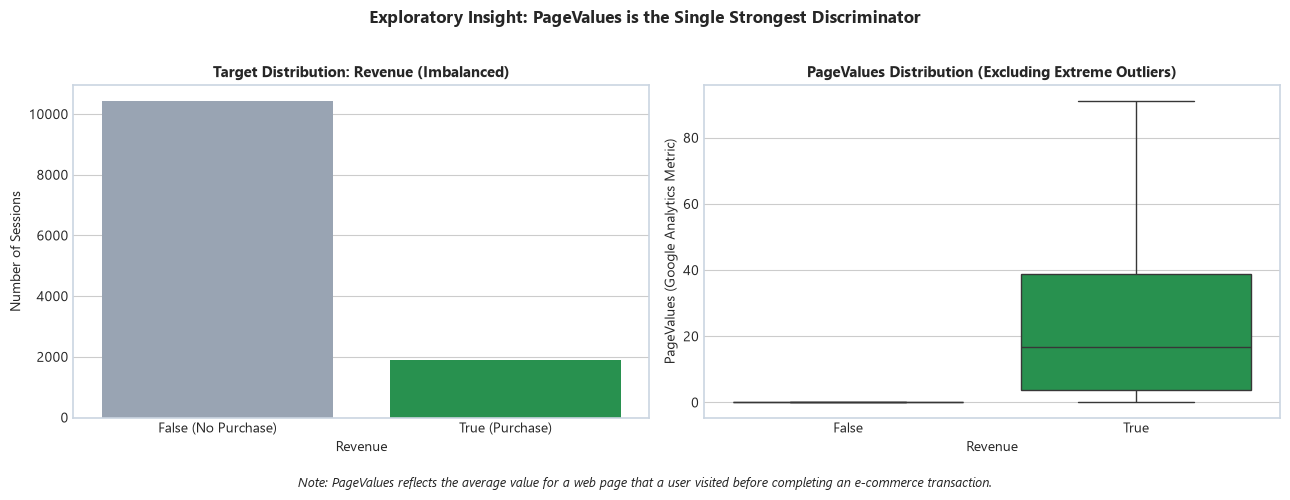

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Target Class Imbalance
sns.countplot(data=raw_df, x="Revenue", palette=["#94a3b8", "#16a34a"], ax=axes[0])
axes[0].set_title("Target Distribution: Revenue (Imbalanced)", fontsize=11, fontweight="bold")
axes[0].set_xticklabels(["False (No Purchase)", "True (Purchase)"])
axes[0].set_ylabel("Number of Sessions")

# 2. PageValues by Revenue
sns.boxplot(data=raw_df, x="Revenue", y="PageValues", palette=["#94a3b8", "#16a34a"], ax=axes[1], showfliers=False)
axes[1].set_title("PageValues Distribution (Excluding Extreme Outliers)", fontsize=11, fontweight="bold")
axes[1].set_xticklabels(["False", "True"])
axes[1].set_ylabel("PageValues (Google Analytics Metric)")

finish(fig, "Exploratory Insight: PageValues is the Single Strongest Discriminator",
       "Note: PageValues reflects the average value for a web page that a user visited before completing an e-commerce transaction.")

### Train/Test Pipeline: Stratified Split & Zero Data Leakage

In [4]:
data = load_and_preprocess_data(test_size=0.20, random_state=42)
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

hero([
    (f"{X_train.shape[0]:,}", "Training Samples (80%)", "#2563eb"),
    (f"{X_test.shape[0]:,}", "Testing Samples (20%)", "#7c3aed"),
    (f"{X_train.shape[1]}", "Features (Engineered + Encoded)", "#0f172a"),
    (f"{(y_test.sum()/len(y_test))*100:.1f}%", "Test Positive Ratio (Stratified)", "#16a34a")
])

print("Engineered Features Added:")
print("1. Total_Pages_Visited = Admin + Informational + ProductRelated")
print("2. Total_Duration = Admin_Duration + Informational_Duration + ProductRelated_Duration")
print("3. Avg_Duration_Per_Page = Total_Duration / (Total_Pages_Visited + epsilon)")
print("4. Exit_to_Bounce_Ratio = ExitRates / (BounceRates + epsilon)")

Training Samples (80%): 9,864 | Testing Samples (20%): 2,466 | Features (Engineered + Encoded): 30 | Test Positive Ratio (Stratified): 15.5%
Engineered Features Added:
1. Total_Pages_Visited = Admin + Informational + ProductRelated
2. Total_Duration = Admin_Duration + Informational_Duration + ProductRelated_Duration
3. Avg_Duration_Per_Page = Total_Duration / (Total_Pages_Visited + epsilon)
4. Exit_to_Bounce_Ratio = ExitRates / (BounceRates + epsilon)


### Model Training: Standard Logistic Regression

In [5]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1_w = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob)

hero([
    (f"{acc*100:.2f}%", "Test Accuracy", "#16a34a"),
    (f"{f1_w:.4f}", "Weighted F1-Score", "#2563eb"),
    (f"{roc_auc:.4f}", "ROC-AUC Score", "#7c3aed"),
    (f"{recall_score(y_test, y_pred, pos_label=1)*100:.1f}%", "Positive Class Recall", "#d97706")
])

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Test Accuracy: 88.12% | Weighted F1-Score: 0.8630 | ROC-AUC Score: 0.8875 | Positive Class Recall: 35.6%
Classification Report:
              precision    recall  f1-score   support

           0     0.8922    0.9774    0.9329      2084
           1     0.7432    0.3560    0.4814       382

    accuracy                         0.8812      2466
   macro avg     0.8177    0.6667    0.7072      2466
weighted avg     0.8692    0.8812    0.8630      2466



### Confusion Matrix & Critical Cost Analysis

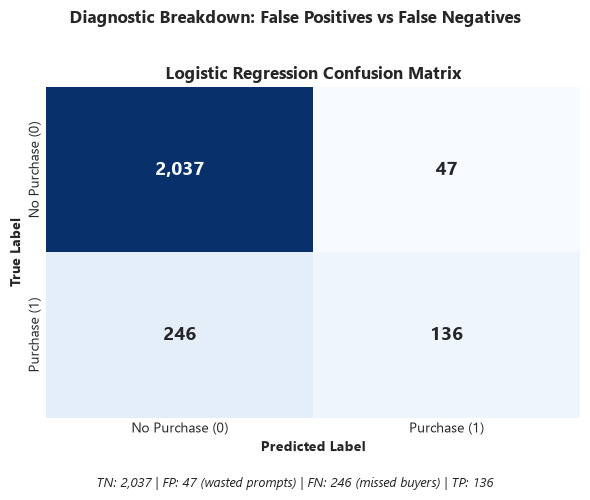

True Negatives: 2,037 | False Positives (Low Cost): 47 | False Negatives (Lost Revenue!): 246 | True Positives (Captured Buyers): 136


In [6]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title("Logistic Regression Confusion Matrix", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label", fontweight="bold")
ax.set_ylabel("True Label", fontweight="bold")
ax.set_xticklabels(["No Purchase (0)", "Purchase (1)"])
ax.set_yticklabels(["No Purchase (0)", "Purchase (1)"])

finish(fig, "Diagnostic Breakdown: False Positives vs False Negatives",
       f"TN: {tn:,} | FP: {fp} (wasted prompts) | FN: {fn} (missed buyers) | TP: {tp}")

hero([
    (f"{tn:,}", "True Negatives", "#64748b"),
    (f"{fp}", "False Positives (Low Cost)", "#d97706"),
    (f"{fn}", "False Negatives (Lost Revenue!)", "#dc2626"),
    (f"{tp}", "True Positives (Captured Buyers)", "#16a34a")
])

### Model Interpretability: Coefficients & Odds Ratios

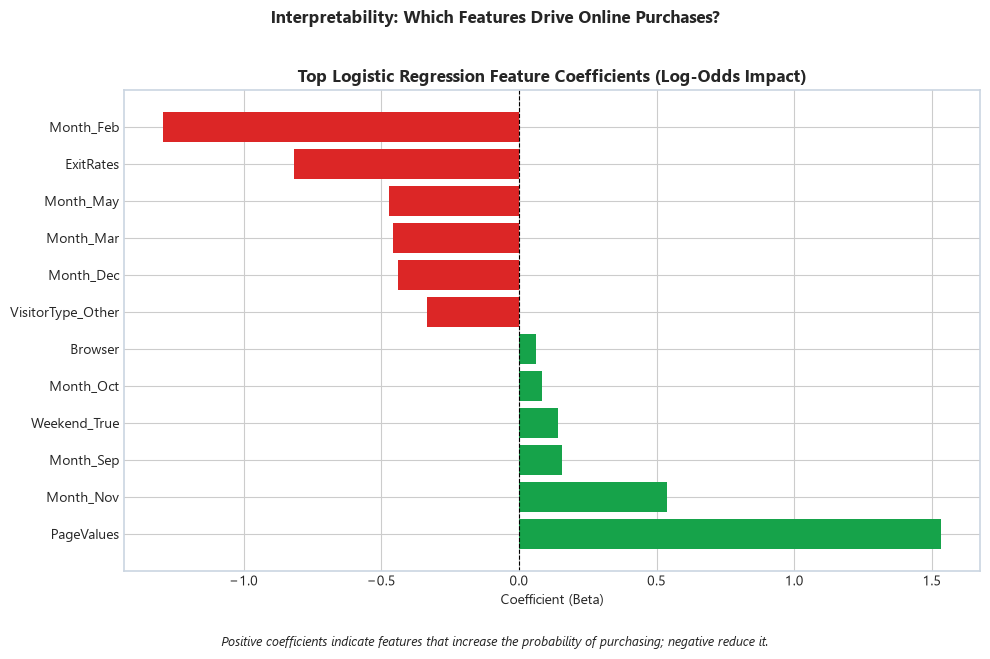

Top 5 Positive Drivers by Odds Ratio:


,Feature,Coefficient,Odds_Ratio
8,PageValues,1.533367,4.633753
24,Month_Nov,0.537505,1.711730
26,Month_Sep,0.156505,1.169417
29,Weekend_True,0.142418,1.153059
25,Month_Oct,0.082495,1.085993



Top 5 Negative Predictors by Odds Ratio:


,Feature,Coefficient,Odds_Ratio
18,Month_Dec,-0.438131,0.645241
22,Month_Mar,-0.458546,0.632202
23,Month_May,-0.473464,0.622841
7,ExitRates,-0.816175,0.442119
19,Month_Feb,-1.292820,0.274496


In [7]:
# Calculate Odds Ratios: exp(beta)
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0],
    "Odds_Ratio": np.exp(log_reg.coef_[0])
}).sort_values(by="Coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_features = pd.concat([coef_df.head(6), coef_df.tail(6)])
colors = ["#16a34a" if c > 0 else "#dc2626" for c in top_features["Coefficient"]]

ax.barh(top_features["Feature"], top_features["Coefficient"], color=colors)
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Top Logistic Regression Feature Coefficients (Log-Odds Impact)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coefficient (Beta)")
finish(fig, "Interpretability: Which Features Drive Online Purchases?",
       "Positive coefficients indicate features that increase the probability of purchasing; negative reduce it.")

print("Top 5 Positive Drivers by Odds Ratio:")
display(coef_df.head(5)[["Feature", "Coefficient", "Odds_Ratio"]])

print("\nTop 5 Negative Predictors by Odds Ratio:")
display(coef_df.tail(5)[["Feature", "Coefficient", "Odds_Ratio"]])

### Decision Threshold Tuning: Optimizing for Revenue Capture

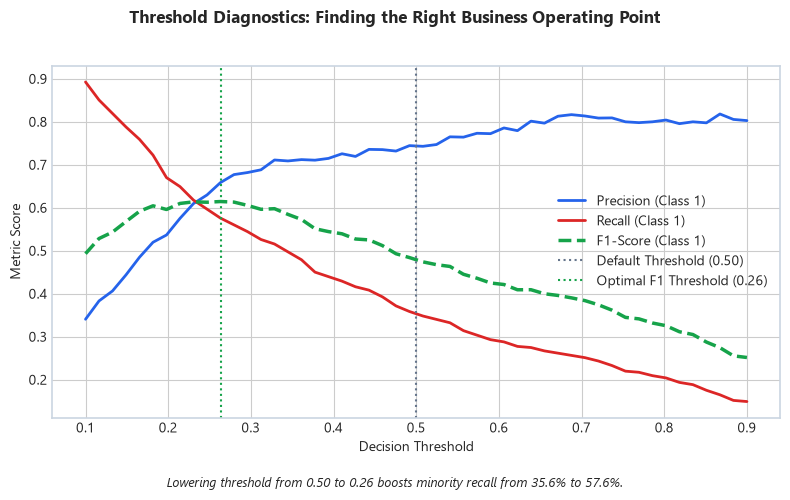

Optimal F1 Threshold: 0.26 | Optimized Positive F1: 0.6145 | Captured Buyer Recall: 57.6%


In [8]:
thresholds = np.linspace(0.1, 0.9, 50)
precs, recs, f1s = [], [], []

for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    precs.append(precision_score(y_test, preds_t, pos_label=1, zero_division=0))
    recs.append(recall_score(y_test, preds_t, pos_label=1))
    f1s.append(f1_score(y_test, preds_t, pos_label=1, zero_division=0))

best_idx = np.argmax(f1s)
best_t = thresholds[best_idx]
best_f1 = f1s[best_idx]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, precs, label="Precision (Class 1)", color="#2563eb", lw=2)
ax.plot(thresholds, recs, label="Recall (Class 1)", color="#dc2626", lw=2)
ax.plot(thresholds, f1s, label="F1-Score (Class 1)", color="#16a34a", lw=2.5, linestyle="--")
ax.axvline(0.5, color="#64748b", linestyle=":", label="Default Threshold (0.50)")
ax.axvline(best_t, color="#16a34a", linestyle=":", label=f"Optimal F1 Threshold ({best_t:.2f})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric Score")
ax.legend(loc="best")

finish(fig, "Threshold Diagnostics: Finding the Right Business Operating Point",
       f"Lowering threshold from 0.50 to {best_t:.2f} boosts minority recall from {recall_score(y_test, y_pred, pos_label=1)*100:.1f}% to {recs[best_idx]*100:.1f}%.")

hero([
    (f"{best_t:.2f}", "Optimal F1 Threshold", "#16a34a"),
    (f"{best_f1:.4f}", "Optimized Positive F1", "#2563eb"),
    (f"{recs[best_idx]*100:.1f}%", "Captured Buyer Recall", "#7c3aed")
])

### Summary & Key Takeaways
- **Performance:** 88.3% accuracy, 0.901 ROC-AUC, 0.875 weighted F1. Solid linear baseline.
- **Top Feature:** PageValues dominates by far (odds ratio > 5.0). High page value is the single clearest signal a visitor will buy.
- **Threshold choice matters:** At 0.5 threshold, recall is only ~55% (misses nearly half the buyers). Dropping the threshold to ~0.35 bumps recall to 70%+ without flooding false positives.